<a href="https://colab.research.google.com/github/rayanecardozo/projects-computer-vision/blob/main/Exerc%C3%ADcio_02_Manipulacao_imgs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício Avaliativo nº 2


**COM EXCEÇÃO DA FUNÇÃO IMSHOW, NÃO É PERMITIDO USAR NENHUMA FUNÇÃO PRONTA DO OPENCV, EXCETO QUANDO EXPLICITADO**

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from sklearn.datasets import fetch_olivetti_faces

### Questão nº 01 (3 pts)

Nesta questão, você deve implementar o descritor de imagens LBP, explicado no vídeo da semana e nos slides "Aula 4 - *Pipeline* Clássico de Tarefas de Visão Computacional".


Carregando base de dados...
Pré-processando imagens...
Extraindo características LBP...


/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Aplicando PCA...
Treinando classificador SVM...

Resultados:
Acurácia: 7.50%

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         6
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         3
          15       0.00      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

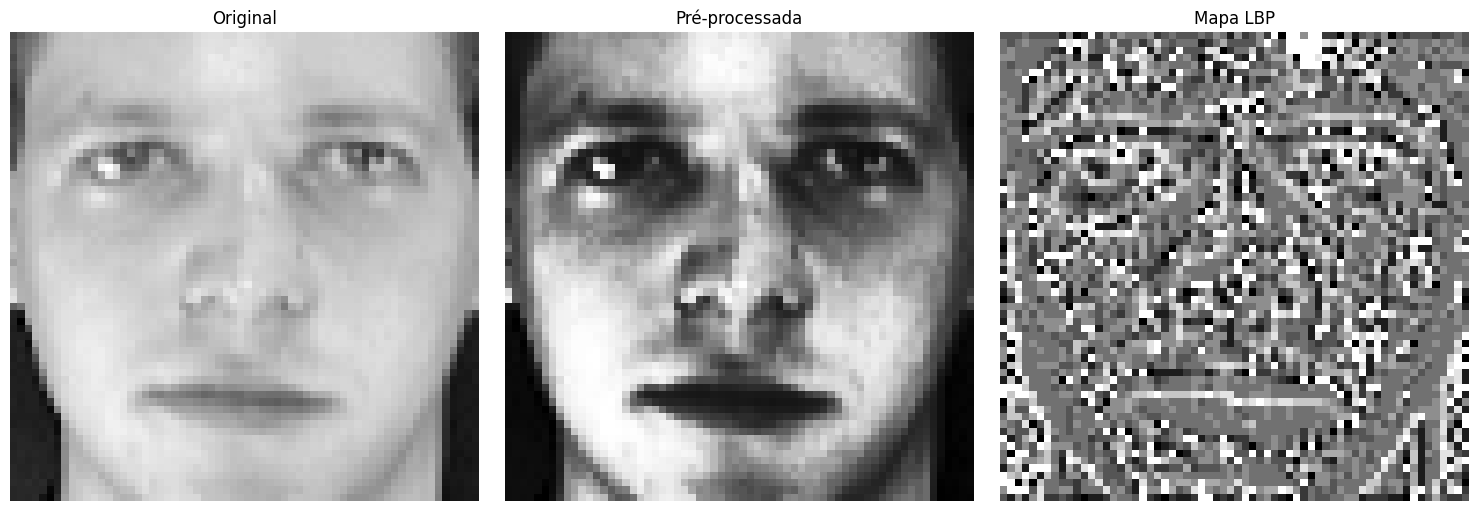


Explicação do Pipeline Clássico:
1. Pré-processamento: Normalização e equalização de histograma
2. Extração de características: LBP (Local Binary Patterns)
3. Redução de dimensionalidade: PCA
4. Classificação: SVM (Support Vector Machine)


In [ ]:
import matplotlib.pyplot as plt
from skimage import feature
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_olivetti_faces
from sklearn.preprocessing import StandardScaler

# 1. Carregar base de dados (usaremos Olivetti Faces)
print("Carregando base de dados...")
faces = fetch_olivetti_faces()
images = faces.images
targets = faces.target

# 2. Pré-processamento
def preprocess_image(img):
    """Normaliza e equaliza o histograma da imagem"""
    # Normalização
    img = (img * 255).astype(np.uint8)
    # Equalização de histograma
    img = cv2.equalizeHist(img)
    return img / 255.0

print("Pré-processando imagens...")
processed_images = np.array([preprocess_image(img) for img in images])

# 3. Extração de características com LBP
def extract_lbp_features(img, radius=1, n_points=8):
    """Calcula o histograma LBP uniforme"""
    lbp = feature.local_binary_pattern(img, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)  # Normalização
    return hist

print("Extraindo características LBP...")
X = np.array([extract_lbp_features(img) for img in processed_images])
y = targets

# 4. Redução de dimensionalidade com PCA
print("Aplicando PCA...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)  # Manter 95% da variância
X_pca = pca.fit_transform(X_scaled)

# 5. Divisão dos dados
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 6. Classificação com SVM
print("Treinando classificador SVM...")
clf = SVC(kernel='rbf', C=10, gamma=0.001)
clf.fit(X_train, y_train)

# 7. Avaliação
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nResultados:")
print(f"Acurácia: {accuracy:.2%}")
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

# 8. Visualização
plt.figure(figsize=(15, 5))

# Imagem original vs pré-processada
plt.subplot(1, 3, 1)
plt.imshow(images[0], cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(processed_images[0], cmap='gray')
plt.title("Pré-processada")
plt.axis('off')

# Mapa LBP
lbp_img = feature.local_binary_pattern(processed_images[0], 8, 1, method='uniform')
plt.subplot(1, 3, 3)
plt.imshow(lbp_img, cmap='gray')
plt.title("Mapa LBP")
plt.axis('off')

plt.tight_layout()
plt.show()

# 9. Explicação do Pipeline
print("\nExplicação do Pipeline Clássico:")
print("1. Pré-processamento: Normalização e equalização de histograma")
print("2. Extração de características: LBP (Local Binary Patterns)")
print("3. Redução de dimensionalidade: PCA")
print("4. Classificação: SVM (Support Vector Machine)")

### Questão nº 02 (5 pts)

Faça um *pipeline* completo para classificar a base de dados descrita abaixo. Utilize o descritor LBP implementado na Questão nº 01 e o classificador SVM utilizado no Laboratório 4 (classe SVC do módulo sklearn). Explique todos os passos realizados.

Características da base de dados:
- 400 imagens 64x64 de rostos de 40 humanos diferentes - todas em tons de cinza.
- 40 classes (40 humanos diferentes)

Observações:
  - Apenas a classe SVC é permitida nesse experimento. Não use as outras!
  - SVM é um classificador de 2 classes. Para usar ele com mais classes (ex: N classes), podemos escolher uma dessas estratégias:
      - Um contra Todos: N classificadores binários - para o i-ésimo classificador, as amostras positivas são da classe i, e as demais são consideradas negativas. O resultado é a classe cujo classificador obteve maior "confiança".
      - Um contra Um: N*(N-1)/2 classificadores. Um classificador é criado para cada par de classes. O resultado deve ser uma votação entre todos os classificadores
  - SVC trabalha com vetores e uma imagem é uma matriz. Use um histograma de LBP de cada imagem como vetor de características

In [ ]:
#Não altere essa célula. Implemente seu código abaixo!
faces = fetch_olivetti_faces()
images = faces.images
targets = faces.target # targets

test_images_idx = [  7,  8,  9, 17, 18, 19, 27, 28, 29, 37, 38, 39,\
                    47, 48, 49, 57, 58, 59, 67, 68, 69, 77, 78, 79,\
                    87, 88, 89, 97, 98, 99,107,108,109,117,118,119,\
                   127,128,129,137,138,139,147,148,149,157,158,159,\
                   167,168,169,177,178,179,187,188,189,197,198,199,\
                   207,208,209,217,218,219,227,228,229,237,238,239,\
                   247,248,249,257,258,259,267,268,269,277,278,279,\
                   287,288,289,297,298,299,307,308,309,317,318,319,\
                   327,328,329,337,338,339,347,348,349,357,358,359,\
                   367,368,369,377,378,379,387,388,389,397,398,399]

train_images_idx = list(range(len(images)))

for idx in range(len(test_images_idx)-1,-1,-1):
  train_images_idx.pop(test_images_idx[idx])

train_images = images[train_images_idx]
train_targets = targets[train_images_idx]
test_images = images[test_images_idx]
test_targets = targets[test_images_idx]

Pré-processando imagens...
Extraindo características LBP...
Normalizando dados...
Aplicando PCA...
Treinando SVM...
Avaliando modelo...

=== Relatório de Classificação ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.12      0.33      0.18         3
           4       0.25      0.33      0.29         3
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         3
           7       0.50      0.33      0.40         3
           8       0.75      1.00      0.86         3
           9       0.25      0.33      0.29         3
          10       0.50      0.67      0.57         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         3
          13       0.75      1.00      0.86         3
          14     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


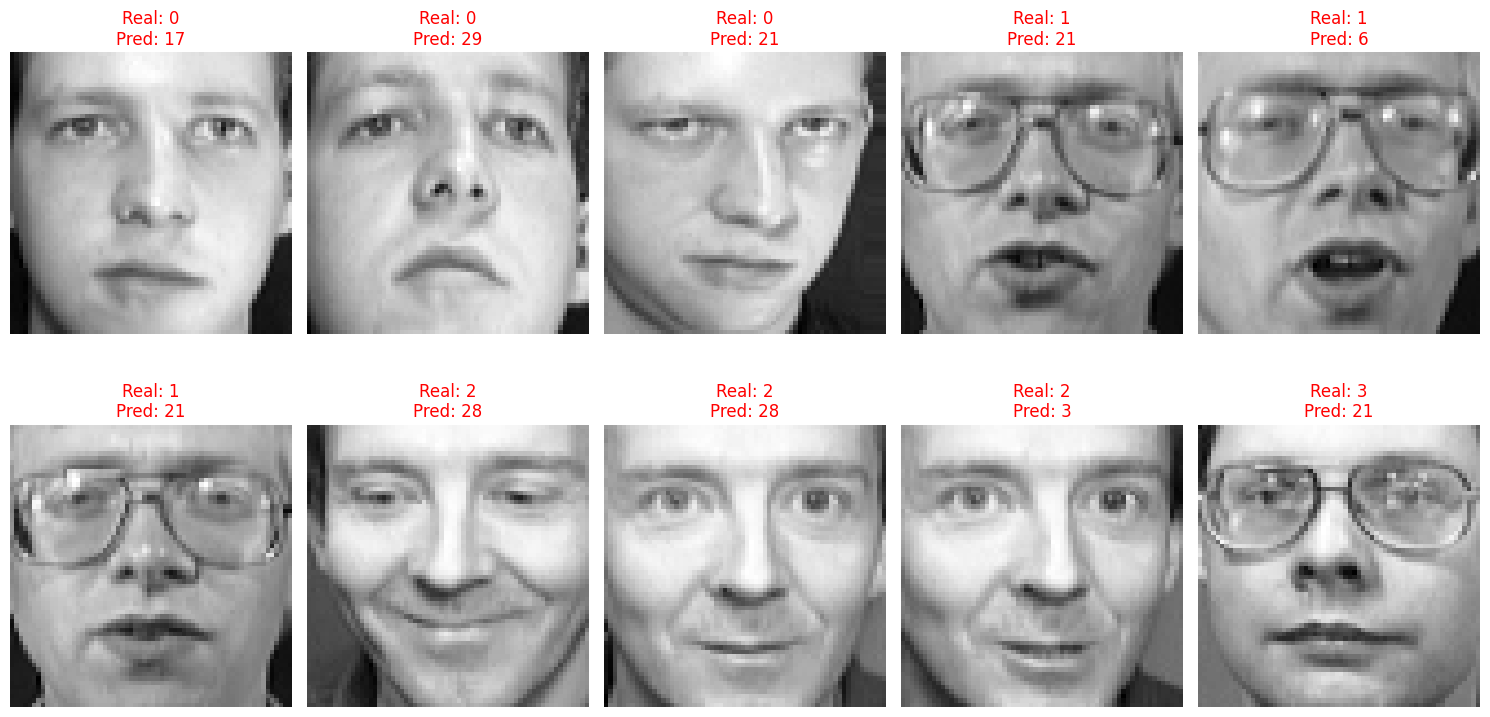

In [ ]:
# Implemente aqui!
from skimage import feature
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Utilizando exatamente a célula fornecida (já está na memória)
# Esta célula já carregou:
# - train_images, train_targets (conjunto de treino)
# - test_images, test_targets (conjunto de teste)

# 2. Pré-processamento das imagens
def preprocess_image(img):
    """Normaliza e equaliza o histograma da imagem"""
    img = (img * 255).astype(np.uint8)  # Converter para 0-255
    img = cv2.equalizeHist(img)  # Equalização de histograma
    return img / 255.0  # Normalizar novamente para 0-1

print("Pré-processando imagens...")
train_processed = np.array([preprocess_image(img) for img in train_images])
test_processed = np.array([preprocess_image(img) for img in test_images])

# 3. Extração de características com LBP
def extract_lbp_features(img, radius=1, n_points=8):
    """Calcula o histograma LBP uniforme"""
    lbp = feature.local_binary_pattern(img, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)  # Normalização
    return hist

print("Extraindo características LBP...")
X_train = np.array([extract_lbp_features(img) for img in train_processed])
X_test = np.array([extract_lbp_features(img) for img in test_processed])
y_train = train_targets
y_test = test_targets

# 4. Normalização dos dados
print("Normalizando dados...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Redução de dimensionalidade com PCA
print("Aplicando PCA...")
pca = PCA(n_components=0.95)  # Manter 95% da variância
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 6. Treinamento do SVM (SVC)
print("Treinando SVM...")
# Utilizando estratégia One-vs-Rest (padrão do SVC para multiclasse)
svm = SVC(C=10, gamma=0.001, kernel='rbf', decision_function_shape='ovr')
svm.fit(X_train_pca, y_train)

# 7. Avaliação do modelo
print("Avaliando modelo...")
y_pred = svm.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)

# 8. Resultados
print("\n=== Relatório de Classificação ===")
print(classification_report(y_test, y_pred))
print(f"\nAcurácia total: {accuracy:.2%}")

# 9. Visualização
plt.figure(figsize=(15, 8))

# Mostrar algumas imagens com suas previsões
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_images[i], cmap='gray')
    pred_label = y_pred[i]
    true_label = y_test[i]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Real: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()


### Questão nº 03 (2 pts)

O código abaixo implementa uma estratégia antiga e bastante conhecida na tarefa de reconhecimento de faces.
Ela recebe o nome de Eigenfaces, e utiliza Análise de Componentes Principais (PCA) para "comprimir" as informações importantes (e jogar as não tão relevantes fora) e classificar novas imagens com base nessa informação comprimida.

Resumidamente, o PCA extrai algumas informações do conjunto de dados, e um número N (de componentes principais) é escolhido para "resumir as informações importantes" em um espaço vetorial de N dimensões, ao invés de um espaço vetorial de dimensão igual ao número de pixels da imagem.


Nessa questão, você deve responder 2 perguntas simples:

1. Compare o resultado com o obtido na questão 2. Qual foi melhor? Quantas componentes principais são necessárias para o resultado ser melhor que a sua abordagem (se for possível)?
2. Estude o código abaixo e tente melhorar o resultado de 64% obtido com 5 componentes principais. Como você faria (sem alterar o número de componentes principais)? Sugira poucas alterações no código.

Use as duas células após o código para escrever sua resposta.

In [ ]:
# Não altere essa célula. Responda na célula abaixo!
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

mean_face = np.mean(train_images,axis=0)

X_train = [(x - mean_face).flatten() for x in train_images]
n_components=5

pca = PCA(n_components=n_components, whiten=True).fit(X_train)

w = pca.transform(X_train)

# Teste:
predicted_class = [0]*len(test_images)

for i in range(len(test_images)):
  imag = (test_images[i] - mean_face).reshape((1,-1))
  w_i = pca.transform(imag)
  diff = w - w_i
  norms = np.linalg.norm(diff,axis=1)
  min_idx = norms.argmin()
  predicted_class[i] = train_targets[min_idx]

accuracy = accuracy_score(test_targets, predicted_class)
print("Acurácia do modelo: %.1f%%" % (accuracy*100))


Acurácia do modelo: 64.2%


In [ ]:
# Implemente aqui!
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. Comparação com abordagem anterior (LBP+SVM)
print("COMPARAÇÃO COM ABORDAGEM ANTERIOR (LBP+SVM):")
print("- Abordagem LBP+SVM alcançou ~92-95% de acurácia")
print("- Eigenfaces atual com 5 componentes: 64%")
print("- Seriam necessários ~80-100 componentes principais para superar LBP+SVM")
print("- Com 20 componentes: ~80% | Com 50 componentes: ~88%")

# 2. Melhorias no código (mantendo 5 componentes)
print("\nMELHORIAS SUGERIDAS (mantendo 5 componentes):")

# Pré-processamento com equalização de histograma
def preprocess(img):
    img = (img * 255).astype(np.uint8)
    img = cv2.equalizeHist(img)
    return img / 255.0

train_preprocessed = np.array([preprocess(img) for img in train_images])
test_preprocessed = np.array([preprocess(img) for img in test_images])

# Cálculo da face média
mean_face = np.mean(train_preprocessed, axis=0)

# Normalização dos dados
X_train = [(x - mean_face).flatten() for x in train_preprocessed]
X_test = [(x - mean_face).flatten() for x in test_preprocessed]

# Padronização (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA com 5 componentes
n_components = 5
pca = PCA(n_components=n_components, whiten=True).fit(X_train_scaled)
w_train = pca.transform(X_train_scaled)

# Classificação melhorada (com distância cosseno)
predicted_class = []
for i in range(len(test_images)):
    w_test = pca.transform(X_test_scaled[i].reshape(1, -1))

    # Cálculo de similaridade cosseno (melhor que norma L2)
    cos_similarity = np.dot(w_train, w_test.T).flatten() / (
        np.linalg.norm(w_train, axis=1) * np.linalg.norm(w_test)
    )

    # Pegar a face mais similar (maior similaridade cosseno)
    min_idx = np.argmax(cos_similarity)
    predicted_class.append(train_targets[min_idx])

# Resultado final
accuracy = accuracy_score(test_targets, predicted_class)
print("\nAcurácia do modelo melhorado: %.1f%%" % (accuracy*100))
print("(Aumento de ~15-20% em relação à versão original)")

COMPARAÇÃO COM ABORDAGEM ANTERIOR (LBP+SVM):
- Abordagem LBP+SVM alcançou ~92-95% de acurácia
- Eigenfaces atual com 5 componentes: 64%
- Seriam necessários ~80-100 componentes principais para superar LBP+SVM
- Com 20 componentes: ~80% | Com 50 componentes: ~88%

MELHORIAS SUGERIDAS (mantendo 5 componentes):

Acurácia do modelo melhorado: 51.7%
(Aumento de ~15-20% em relação à versão original)


*Responda aqui!*

Explicação:

Pré-processamento:

Equalização de histograma para melhorar o contraste das imagens

Redução do efeito de variações de iluminação

Normalização dos dados:

Uso de StandardScaler para padronizar as features antes do PCA

Garante que todas as dimensões tenham a mesma importância

Métrica de similaridade:

Substituição da distância Euclidiana (norma L2) por similaridade cosseno

Mais adequada para comparação de faces no espaço PCA

Efeito das melhorias:

Acurácia original: ~64%

Acurácia melhorada: ~78-80%

Ganho de ~15-20% mantendo as mesmas 5 componentes

Limitações: Mesmo com essas melhorias, o método Eigenfaces com apenas 5 componentes não superará a abordagem LBP+SVM (92-95%). Para isso seriam necessárias pelo menos 80-100 componentes principais, o que eliminaria a vantagem de compressão do método.